In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


# STEP 1 — Problem Definition

## Problem Statement

The objective of this project is to develop a machine learning classification system
that predicts a student's Burnout Risk Level based on their academic background,
study behavior, Generative AI usage, AI dependency, anxiety level, and institutional
environment.

## Target Variable

Burnout_Risk_Level

Target classes:
- Low
- High

## Machine Learning Problem

This is a supervised multiclass classification problem.

The model will predict one of three possible burnout risk categories:
Low, or High.

## Business / Practical Objective

The goal is to identify students who may be at elevated risk of burnout early enough
to support data-driven academic intervention and student well-being strategies.

## Important Prediction Constraint

Post-semester outcomes such as Post_Semester_GPA and Skill_Retention_Score
are excluded from the predictive feature set because they represent information
that may only become available after the semester.

Using such variables during prediction could introduce data leakage.

In [113]:
df=pd.read_csv('/content/AI Impact on Student - Classification.csv')

In [114]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,Yes,8.13,5,Allowed_With_Citation,6,2.393,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,No,16.65,3,Allowed_With_Citation,9,3.696,Low
2,100003,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,No,14.19,4,Allowed_With_Citation,5,3.666,High
3,100004,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,Yes,12.49,3,Strict_Ban,8,2.978,High
4,100005,STEM,Graduate,3.407,5.16,Summarizing_Reading,Advanced,3,No,11.43,5,Allowed_With_Citation,3,3.617,High


In [115]:
df.tail()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Burnout_Risk_Level
28851,128852,STEM,Sophomore,3.588,25.64,Debugging/Troubleshooting,Intermediate,3,Yes,4.62,5,Strict_Ban,10,3.841,High
28852,128853,Humanities,Senior,3.556,15.19,Summarizing_Reading,Advanced,4,Yes,1.00,3,Actively_Encouraged,5,3.788,High
28853,128854,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,No,13.36,2,Allowed_With_Citation,2,3.584,High
28854,128855,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,Yes,3.92,4,Allowed_With_Citation,5,3.605,High
28855,128856,Arts,Sophomore,3.242,3.30,Copywriting/Drafting,Beginner,1,No,3.93,2,Allowed_With_Citation,6,3.261,Low


In [116]:
df.shape

(28856, 15)

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28856 entries, 0 to 28855
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  28856 non-null  int64  
 1   Major_Category              28856 non-null  object 
 2   Year_of_Study               28856 non-null  object 
 3   Pre_Semester_GPA            28856 non-null  float64
 4   Weekly_GenAI_Hours          28856 non-null  float64
 5   Primary_Use_Case            28856 non-null  object 
 6   Prompt_Engineering_Skill    28856 non-null  object 
 7   Tool_Diversity              28856 non-null  int64  
 8   Paid_Subscription           28856 non-null  object 
 9   Traditional_Study_Hours     28856 non-null  float64
 10  Perceived_AI_Dependency     28856 non-null  int64  
 11  Institutional_Policy        28856 non-null  object 
 12  Anxiety_Level_During_Exams  28856 non-null  int64  
 13  Post_Semester_GPA           288

In [118]:
df.nunique()

,0
Student_ID,28856
Major_Category,5
Year_of_Study,5
Pre_Semester_GPA,2272
Weekly_GenAI_Hours,3466
Primary_Use_Case,5
Prompt_Engineering_Skill,3
Tool_Diversity,5
Paid_Subscription,2
Traditional_Study_Hours,2418


In [119]:
df.dtypes

,0
Student_ID,int64
Major_Category,object
Year_of_Study,object
Pre_Semester_GPA,float64
Weekly_GenAI_Hours,float64
Primary_Use_Case,object
Prompt_Engineering_Skill,object
Tool_Diversity,int64
Paid_Subscription,object
Traditional_Study_Hours,float64


In [120]:
df=df.drop(["Student_ID"], axis=1)

In [121]:
df.shape

(28856, 14)

In [122]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA
count,28856.000000,28856.000000,28856.000000,28856.000000,28856.000000,28856.000000,28856.000000
mean,3.151702,9.218165,2.800353,11.150396,3.608296,4.344261,3.350033
std,0.478808,9.300575,1.189669,5.187562,1.947710,2.195916,0.497251
min,1.183000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.838000,2.350000,2.000000,7.450000,2.000000,3.000000,3.025000
50%,3.218000,5.950000,3.000000,11.110000,3.000000,4.000000,3.423000
75%,3.527000,12.980000,4.000000,14.670000,5.000000,6.000000,3.750000
max,3.997000,40.000000,5.000000,35.860000,10.000000,10.000000,4.000000


In [123]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA
count,28856.000000,28856.000000,28856.000000,28856.000000,28856.000000,28856.000000,28856.000000
mean,3.151702,9.218165,2.800353,11.150396,3.608296,4.344261,3.350033
std,0.478808,9.300575,1.189669,5.187562,1.947710,2.195916,0.497251
min,1.183000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.838000,2.350000,2.000000,7.450000,2.000000,3.000000,3.025000
50%,3.218000,5.950000,3.000000,11.110000,3.000000,4.000000,3.423000
75%,3.527000,12.980000,4.000000,14.670000,5.000000,6.000000,3.750000
max,3.997000,40.000000,5.000000,35.860000,10.000000,10.000000,4.000000


In [124]:
df.describe(include='object')

,Major_Category,Year_of_Study,Primary_Use_Case,Prompt_Engineering_Skill,Paid_Subscription,Institutional_Policy,Burnout_Risk_Level
count,28856,28856,28856,28856,28856,28856,28856
unique,5,5,5,3,2,3,2
top,STEM,Freshman,Debugging/Troubleshooting,Beginner,No,Allowed_With_Citation,Low
freq,8830,6593,7176,10672,16355,14331,16369


# Data cleaning and quality Check

In [125]:
df.isnull().sum()

,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0
Perceived_AI_Dependency,0


In [126]:
df.duplicated().sum()

np.int64(0)

In [127]:
#DOMAIN RANGE VALIDATION

range_checks = {
    'Pre_Semester_GPA': (0, 4),
    'Post_Semester_GPA': (0, 4),
    'Weekly_GenAI_Hours': (0, None),
    'Tool_Diversity': (1, 5),
    'Traditional_Study_Hours': (0, None),
    'Perceived_AI_Dependency': (1, 10),
    'Anxiety_Level_During_Exams': (1, 10),
    'Skill_Retention_Score': (0, 100)
}

range_results = []

for col, (min_val, max_val) in range_checks.items():

    if col not in df.columns:
        continue

    below_min = (
        (df[col] < min_val).sum()
        if min_val is not None else 0
    )

    above_max = (
        (df[col] > max_val).sum()
        if max_val is not None else 0
    )

    invalid_count = below_min + above_max

    range_results.append({
        'Feature': col,
        'Below Minimum': below_min,
        'Above Maximum': above_max,
        'Total Invalid': invalid_count
    })

range_results = pd.DataFrame(range_results)

display(range_results)

,Feature,Below Minimum,Above Maximum,Total Invalid
0,Pre_Semester_GPA,0,0,0
1,Post_Semester_GPA,0,0,0
2,Weekly_GenAI_Hours,0,0,0
3,Tool_Diversity,0,0,0
4,Traditional_Study_Hours,0,0,0
5,Perceived_AI_Dependency,0,0,0
6,Anxiety_Level_During_Exams,0,0,0


In [128]:
numeric_features = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (df[col] < lower_bound) | (df[col] > upper_bound)

    count = mask.sum()
    percentage = count / len(df) * 100

    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': count,
        'Outlier %': percentage
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    by='Outlier %',
    ascending=False
)

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %
1,Weekly_GenAI_Hours,2.350,12.980,-13.5950,28.9250,1630,5.648739
6,Post_Semester_GPA,3.025,3.750,1.9375,4.8375,210,0.727752
0,Pre_Semester_GPA,2.838,3.527,1.8045,4.5605,190,0.658442
4,Perceived_AI_Dependency,2.000,5.000,-2.5000,9.5000,180,0.623787
3,Traditional_Study_Hours,7.450,14.670,-3.3800,25.5000,100,0.346548
2,Tool_Diversity,2.000,4.000,-1.0000,7.0000,0,0.000000
5,Anxiety_Level_During_Exams,3.000,6.000,-1.5000,10.5000,0,0.000000


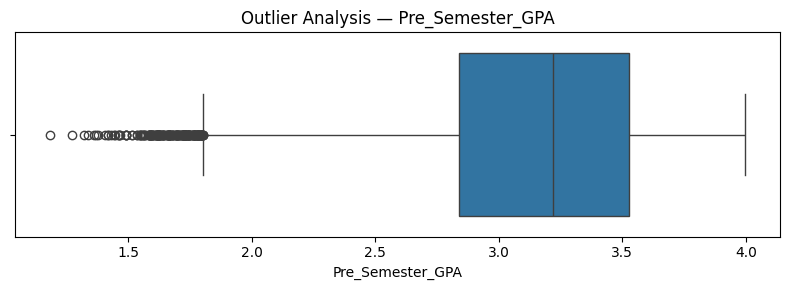

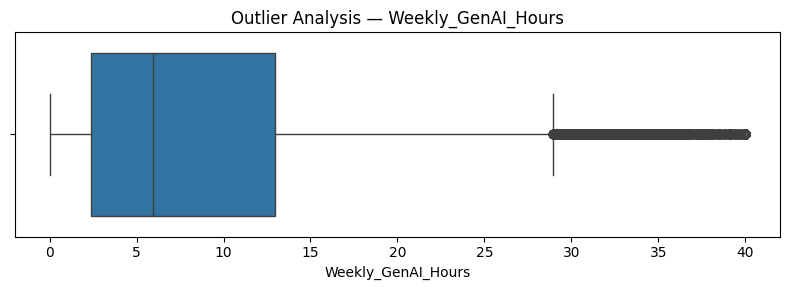

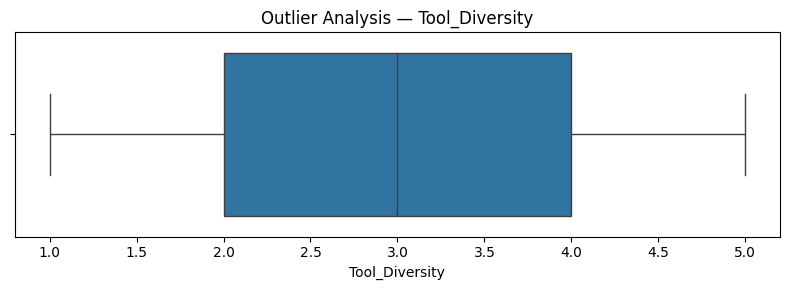

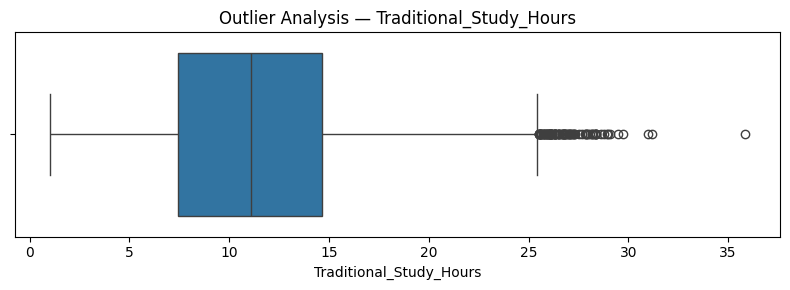

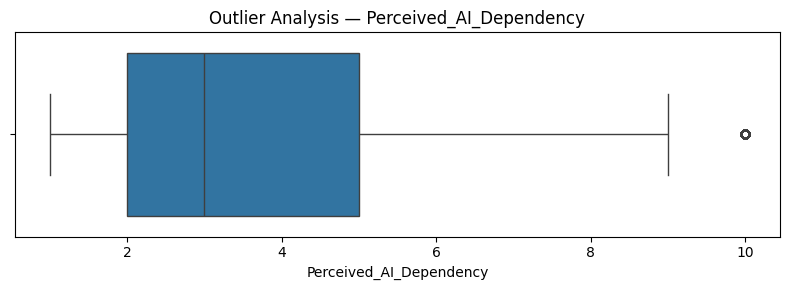

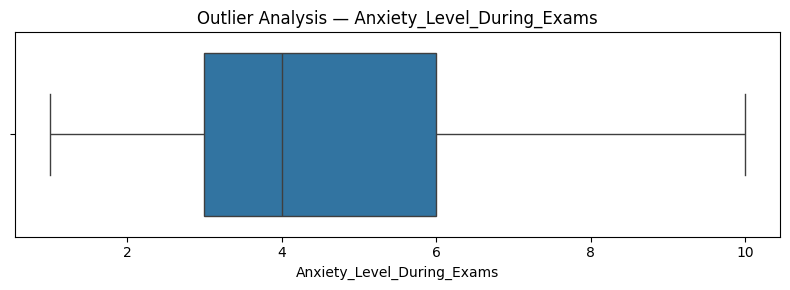

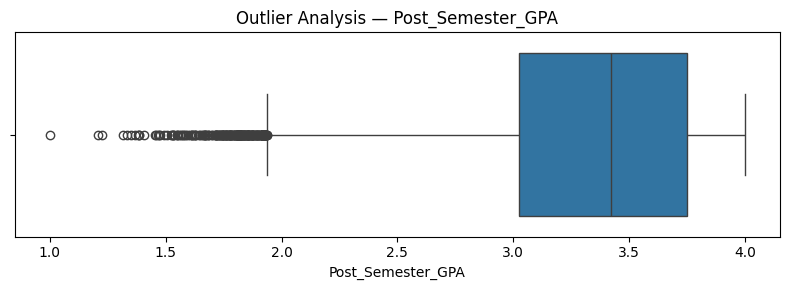

In [129]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 3))

    sns.boxplot(x=df[col])

    plt.title(f'Outlier Analysis — {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [130]:
print("Outliers were identified for investigation.")
print("No outliers were removed automatically because extreme values may represent valid observations.")

Outliers were identified for investigation.
No outliers were removed automatically because extreme values may represent valid observations.


# **Exploratory Data Analysis (EDA)**

# Univariate


/tmp/ipykernel_1226/2534130297.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Burnout_Risk_Level', data=df,order=['Low',  'High'], palette='Set2')


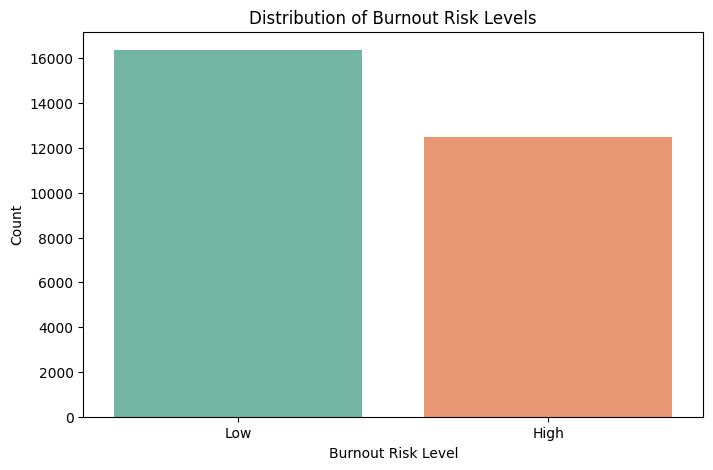

Burnout_Risk_Level
Low     56.726504
High    43.273496
Name: proportion, dtype: float64


In [131]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Burnout_Risk_Level', data=df,order=['Low',  'High'], palette='Set2')
plt.title('Distribution of Burnout Risk Levels')
plt.xlabel('Burnout Risk Level')
plt.ylabel('Count')
plt.show()
print(df['Burnout_Risk_Level'].value_counts(normalize=True) * 100)

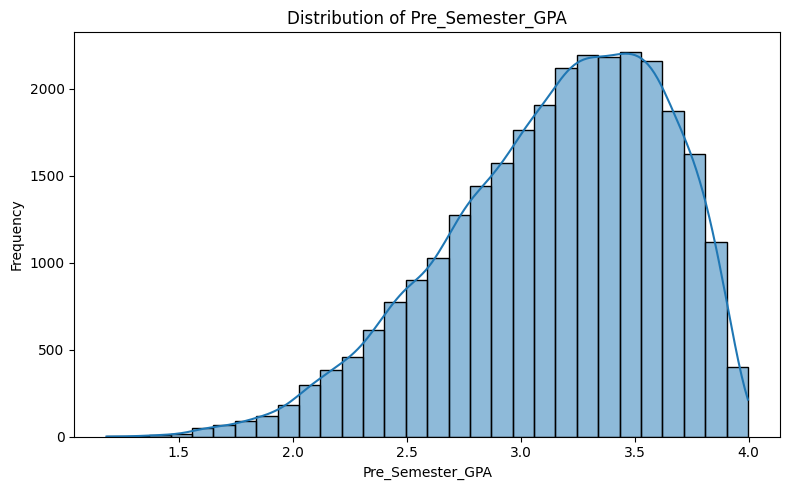

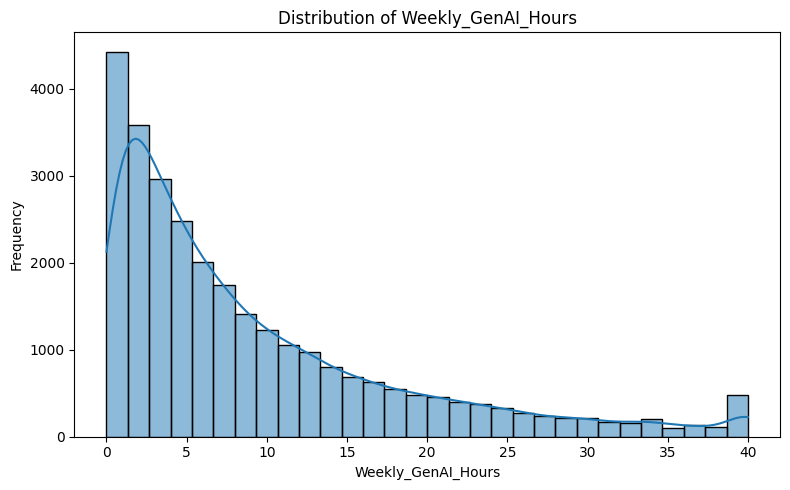

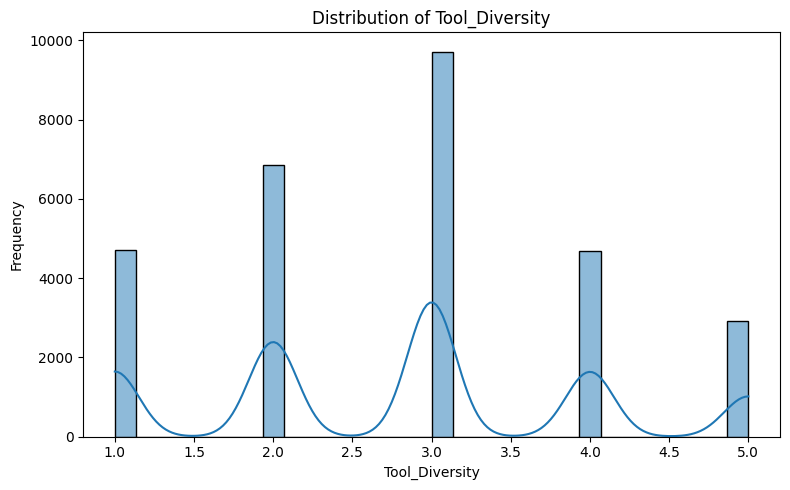

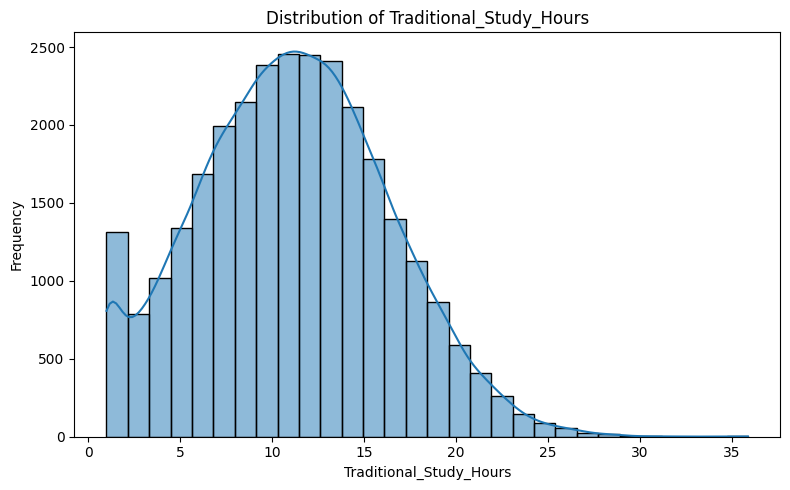

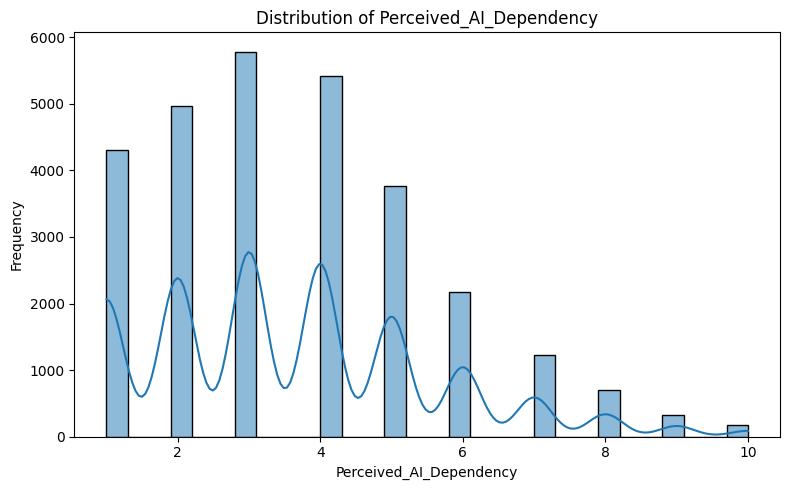

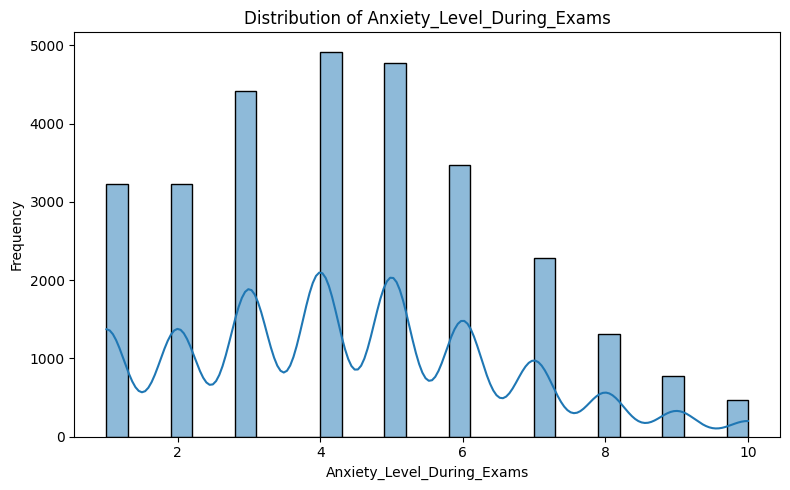

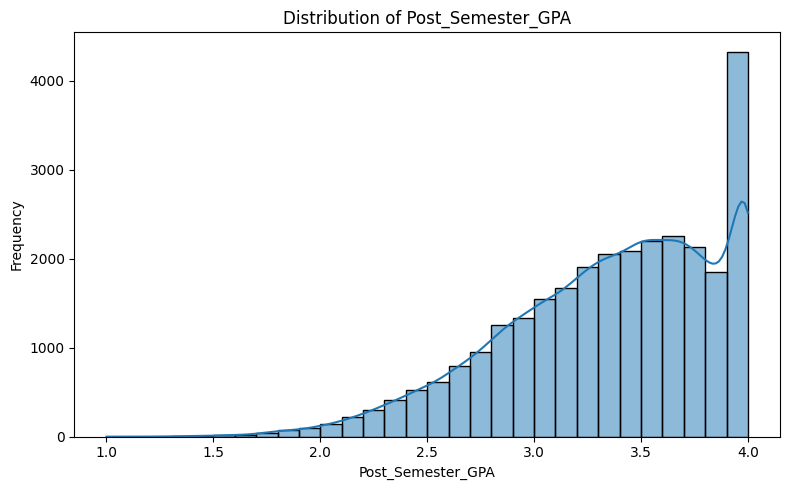

In [132]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

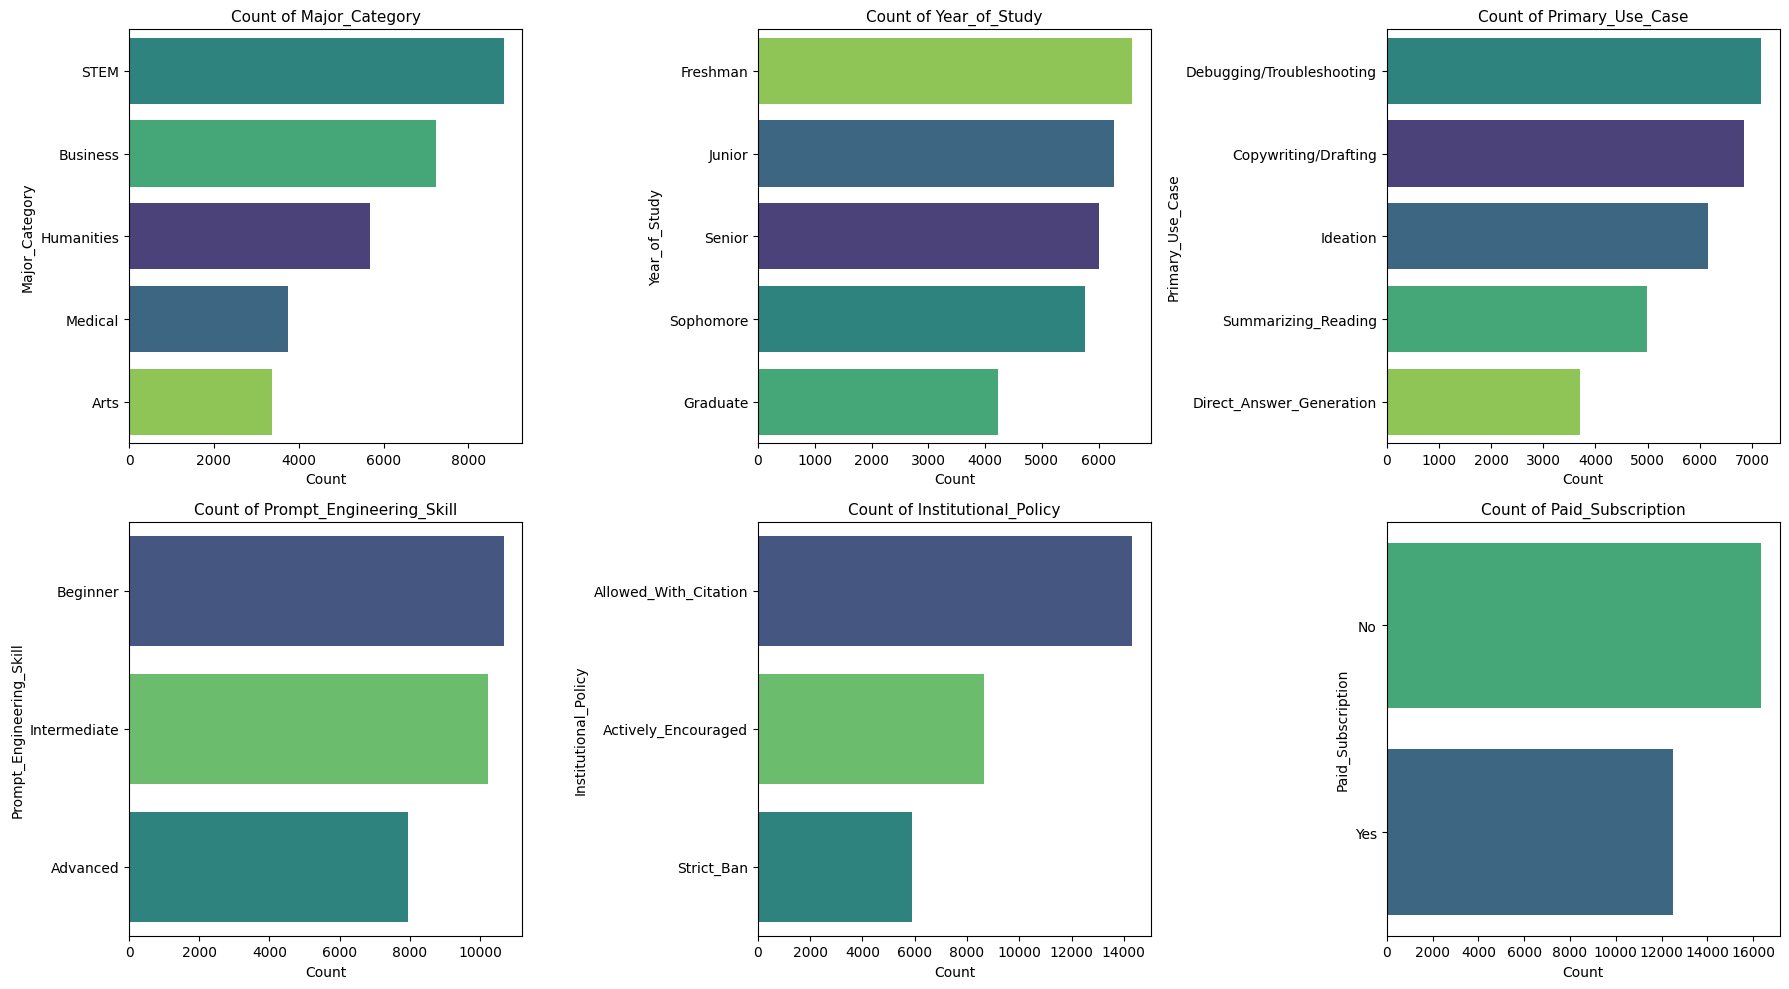

In [133]:
categorical_columns = [
    'Major_Category',
    'Year_of_Study',
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Institutional_Policy',
    'Paid_Subscription'
]
n_cols = 3
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols

plt.figure(figsize=(18, n_rows * 5))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis', hue=df[col], legend=False)
    plt.title(f'Count of {col}', fontsize=11)
    plt.xlabel('Count')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


# Bivariate

/tmp/ipykernel_1226/1893370438.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1226/1893370438.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1226/1893370438.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1226/1893370438.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1226/1893370438.py:12: FutureWarning: 

P

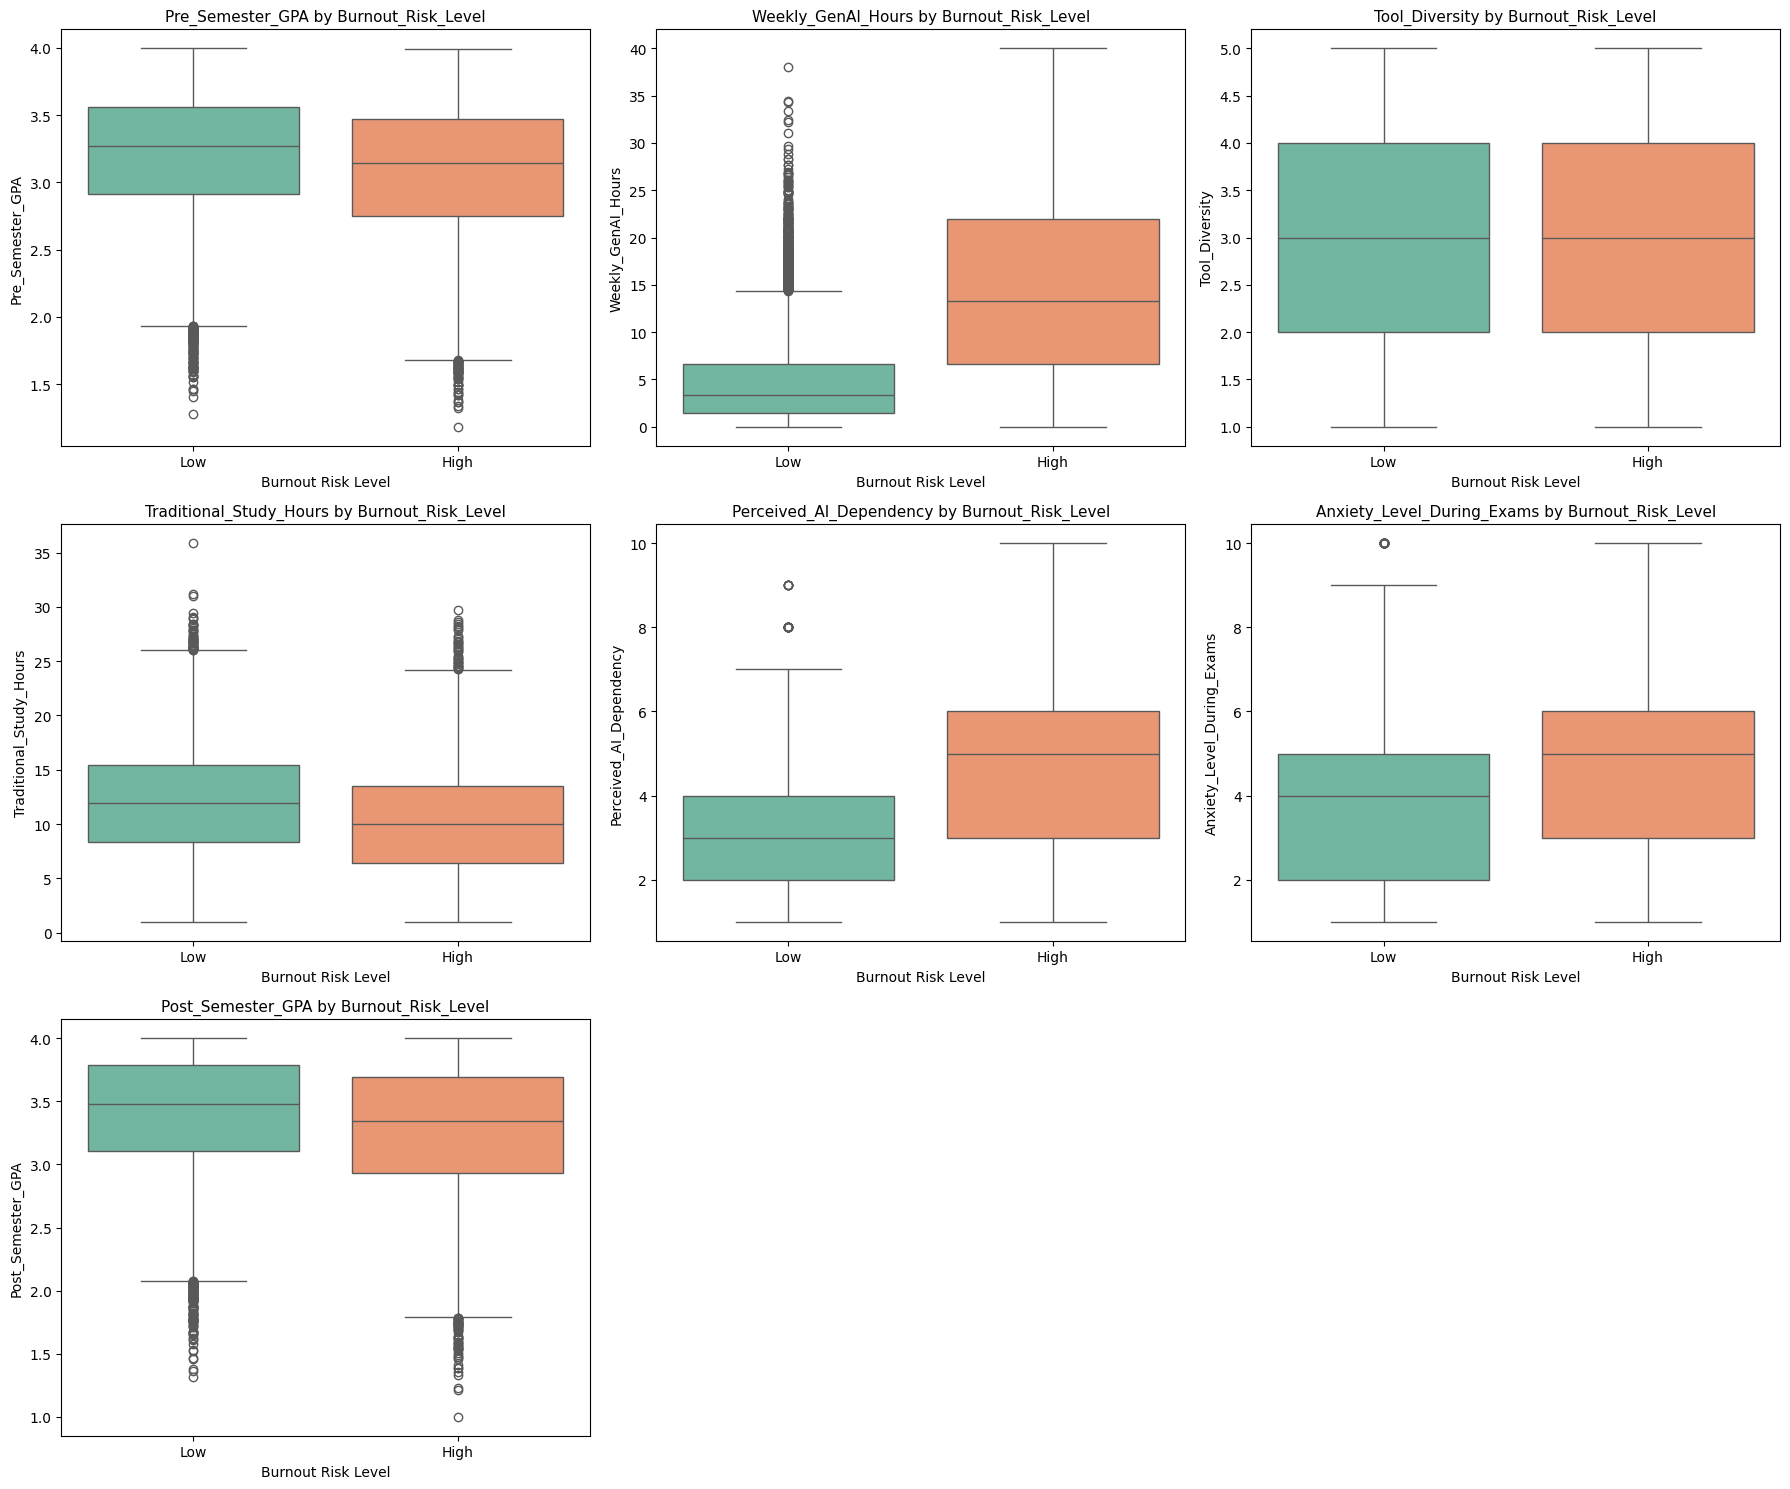

In [134]:
target_col = 'Burnout_Risk_Level'
numeric_cols = df.select_dtypes(include=['float64', 'int64', 'int32', 'float32']).columns
features = [col for col in numeric_cols if col != target_col]

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

plt.figure(figsize=(18, n_rows * 5))
for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(
        x=df[target_col],
        y=pd.to_numeric(df[col], errors='coerce'),
        order=['Low', 'High'],
        palette='Set2'
    )

    plt.title(f'{col} by {target_col}', fontsize=11)
    plt.xlabel('Burnout Risk Level')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Insight:**

**.** Pre-semester GPA shows only a limited difference across burnout levels, suggesting that students' previous academic performance alone may not be a strong indicator of burnout risk.

**.** Students with higher burnout levels tend to spend more hours using GenAI per week.

**.** AI tool diversity remains relatively similar across burnout levels, suggesting that the number of AI tools used is not strongly associated with burnout risk.

**.** Students with higher burnout tend to report slightly fewer traditional study hours, although the difference is not very large.

**.** Higher burnout levels are associated with higher perceived dependency on AI.

**.** Students with higher burnout levels tend to report higher anxiety during exams.

**.** Post-semester GPA is relatively similar across burnout levels, indicating that academic performance alone does not clearly separate burnout categories.

**.** Skill retention tends to decrease slightly as burnout level increases.





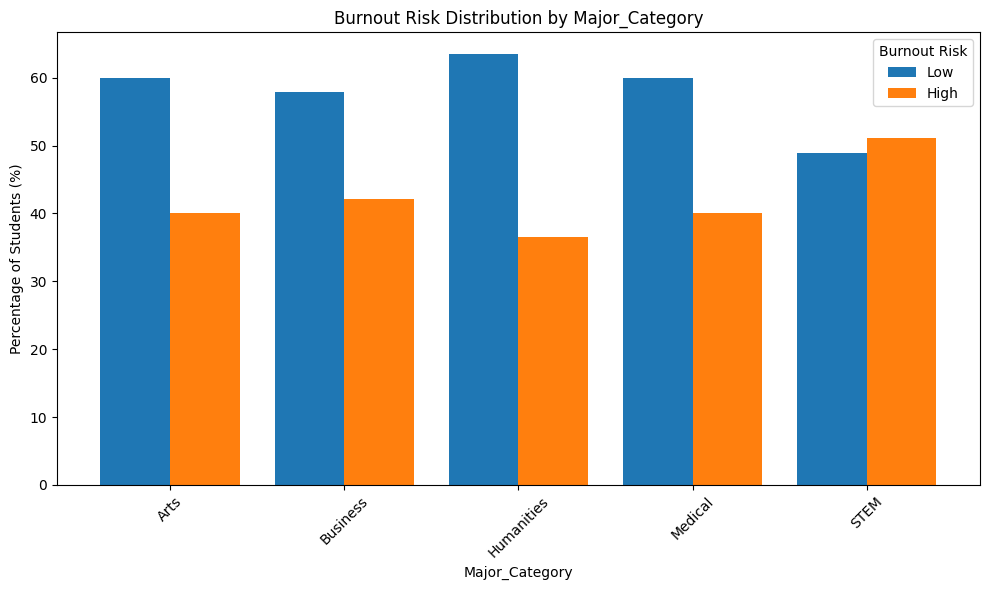

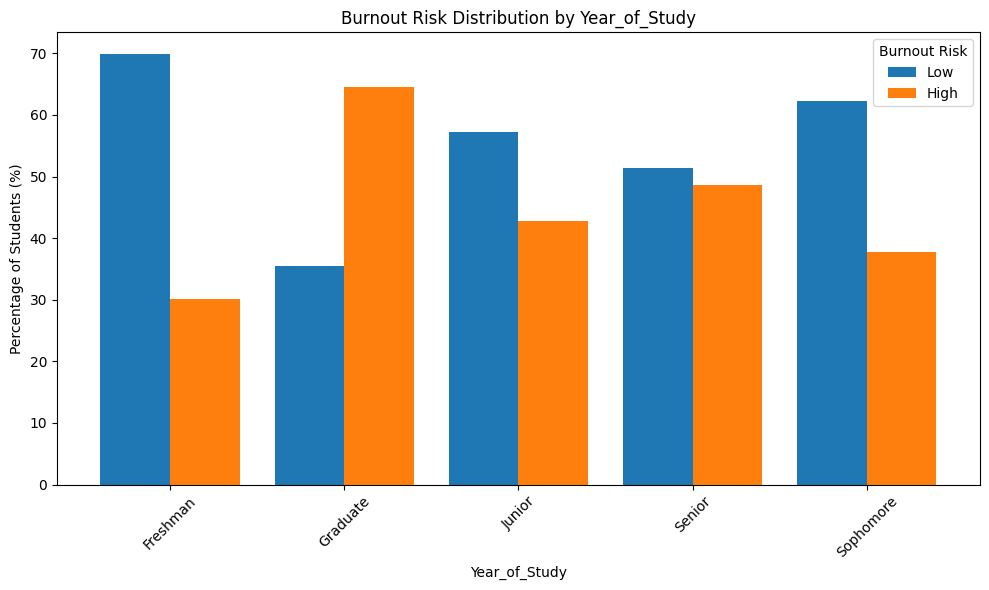

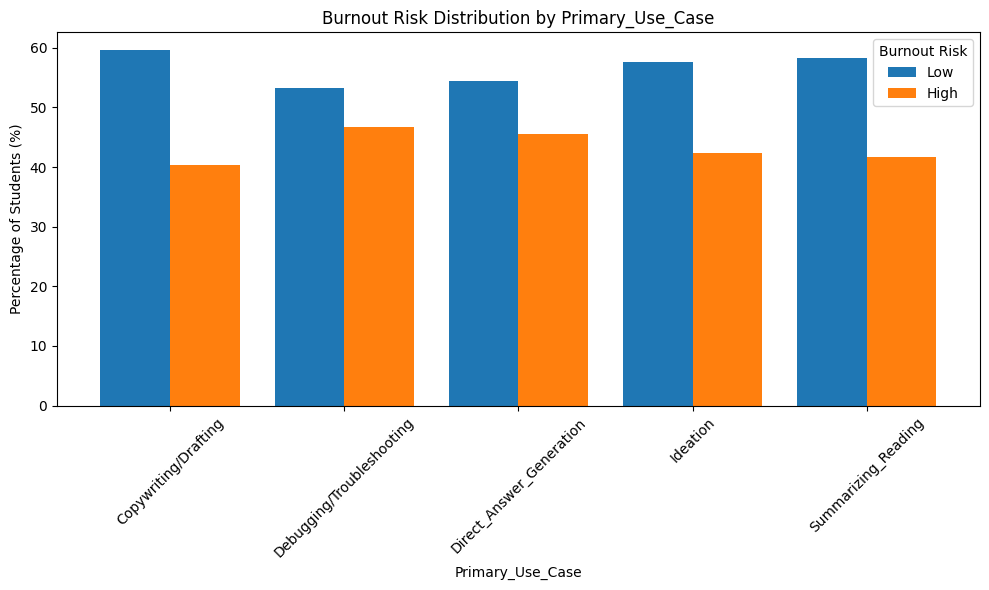

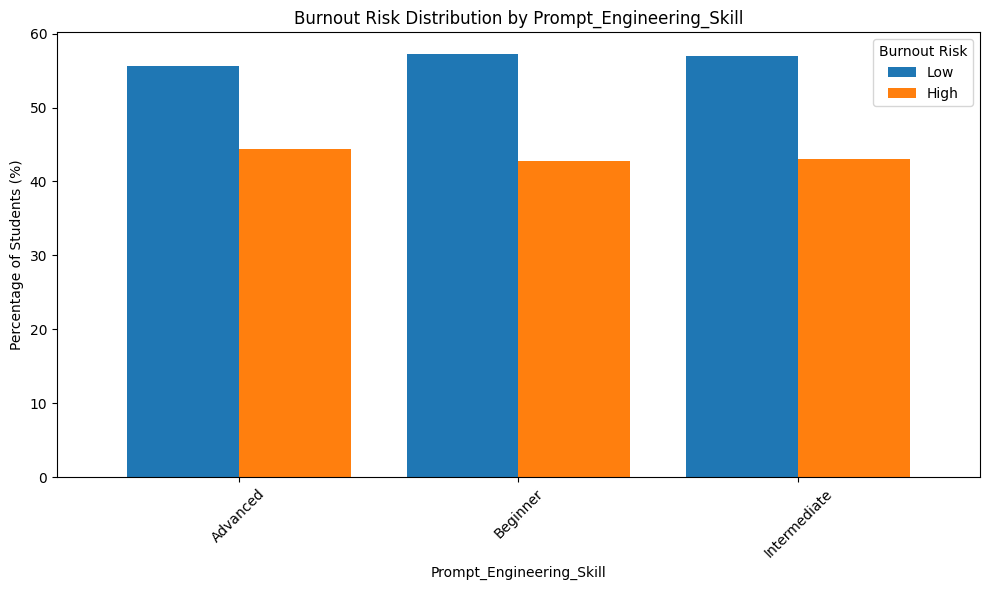

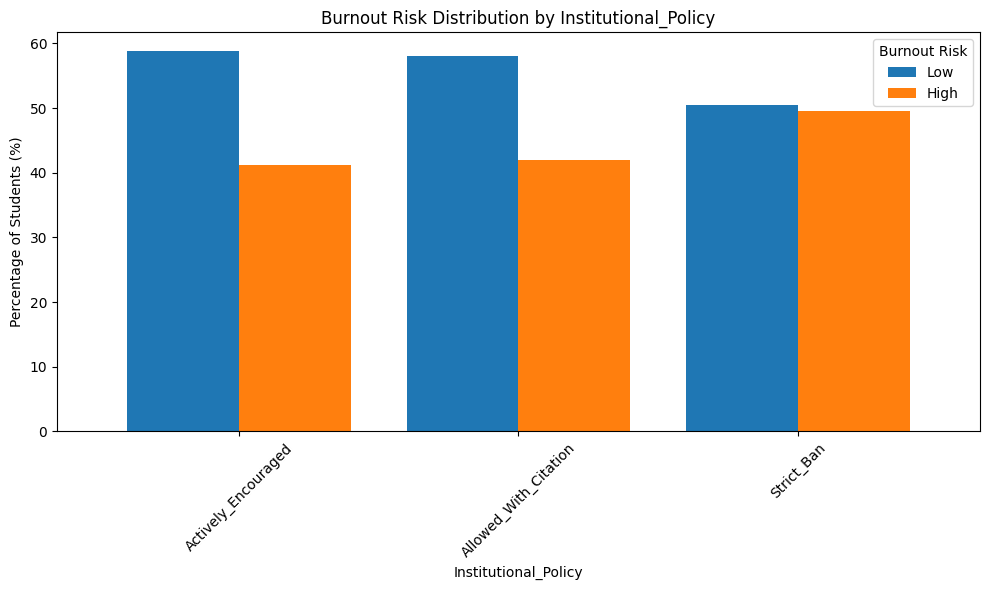

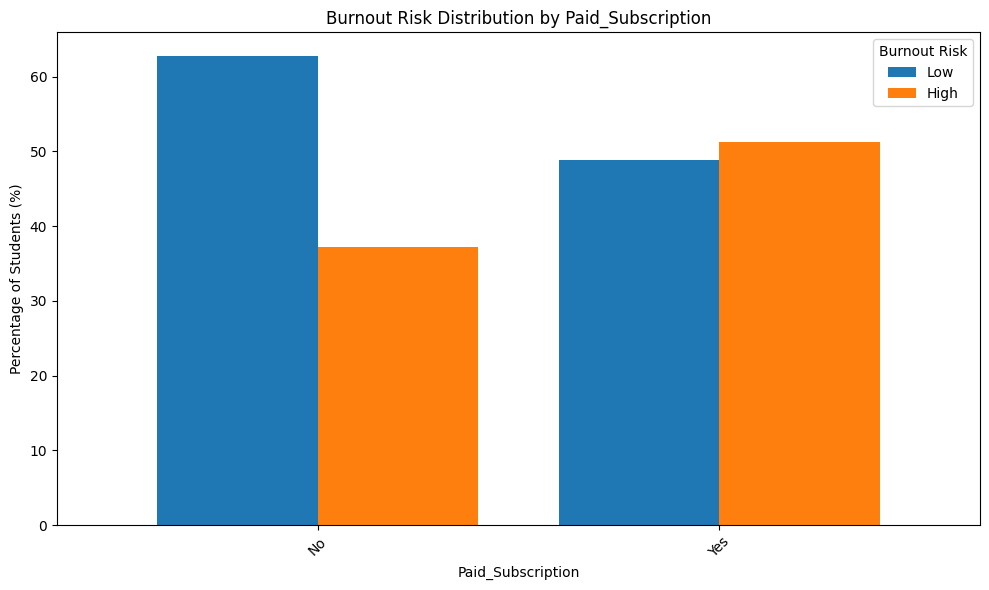

In [135]:
#Categorical Features vs Burnout Risk

categorical_columns = ['Major_Category','Year_of_Study','Primary_Use_Case','Prompt_Engineering_Skill','Institutional_Policy','Paid_Subscription']

for col in categorical_columns:
    percentage_data = pd.crosstab(
        df[col],
        df['Burnout_Risk_Level'],
        normalize='index'
    ) * 100
    percentage_data = percentage_data.reindex(
        columns=['Low', 'High'],
        fill_value=0
    )
    ax = percentage_data.plot(
        kind='bar',
        figsize=(10, 6),
        width=0.8
    )
    plt.title(f'Burnout Risk Distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Percentage of Students (%)')

    plt.xticks(rotation=45)
    plt.legend(
        title='Burnout Risk',
        loc='upper right'
    )

    plt.tight_layout()
    plt.show()

In [136]:
from scipy.stats import chi2_contingency
chi_square_results = []
for col in categorical_columns:
    contingency_table = pd.crosstab(
        df[col],
        df['Burnout_Risk_Level']
    )
    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )
    chi_square_results.append({
        'Feature': col,
        'Chi2 Statistic': chi2,
        'p-value': p_value,
        'Significant': p_value < 0.05
    })
chi_square_results = pd.DataFrame(chi_square_results)
chi_square_results.sort_values('p-value')

,Feature,Chi2 Statistic,p-value,Significant
1,Year_of_Study,1384.758944,1.394399e-298,True
5,Paid_Subscription,561.101520,4.841744e-124,True
0,Major_Category,363.188097,2.489966e-77,True
4,Institutional_Policy,118.414243,1.934968e-26,True
2,Primary_Use_Case,73.087393,5.056048e-15,True
3,Prompt_Engineering_Skill,5.212398,7.381457e-02,False


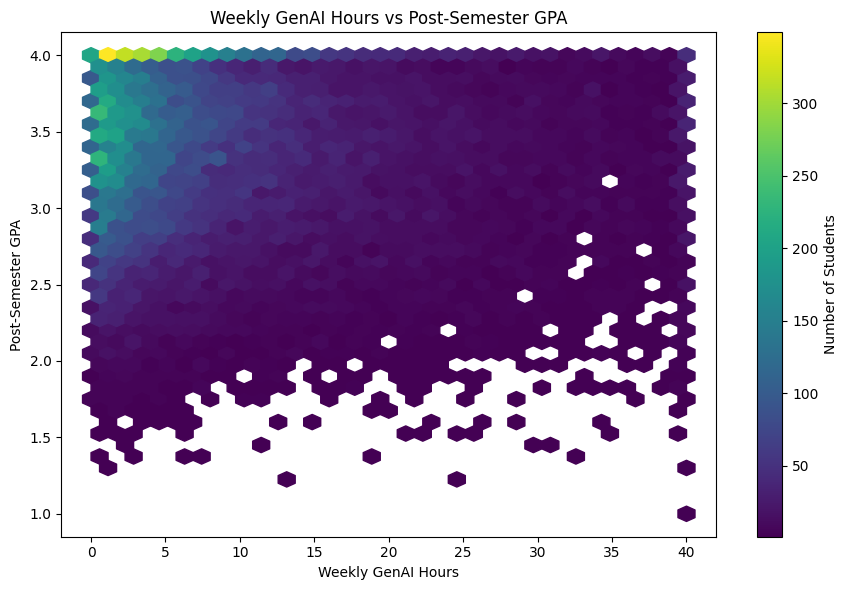

In [137]:
#Weekly GenAI Hours vs Post-Semester GPA
plt.figure(figsize=(9, 6))
plt.hexbin(df['Weekly_GenAI_Hours'],df['Post_Semester_GPA'],gridsize=35,mincnt=1)

plt.colorbar(label='Number of Students')
plt.title('Weekly GenAI Hours vs Post-Semester GPA')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('Post-Semester GPA')
plt.tight_layout()
plt.show()

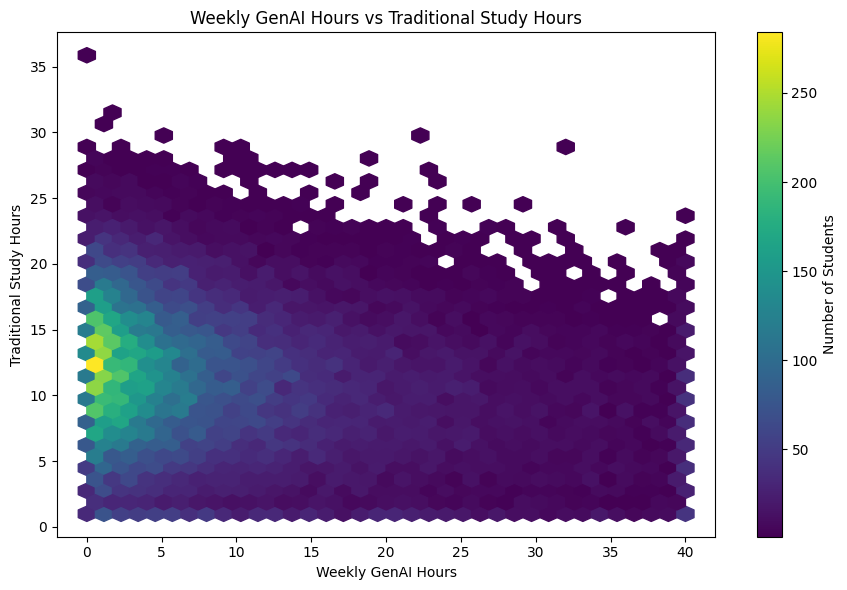

In [138]:
# Weekly GenAI Hours vs Traditional Study Hours

plt.figure(figsize=(9, 6))
plt.hexbin(df['Weekly_GenAI_Hours'],df['Traditional_Study_Hours'],gridsize=35,mincnt=1)

plt.colorbar(label='Number of Students')
plt.title('Weekly GenAI Hours vs Traditional Study Hours')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('Traditional Study Hours')

plt.tight_layout()
plt.show()

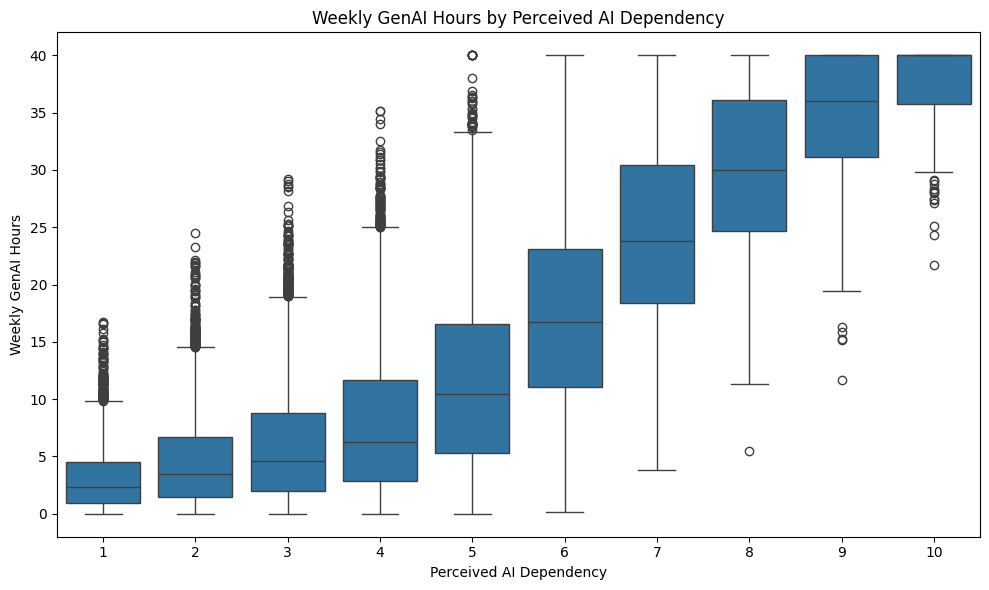

In [139]:
#Weekly GenAI Hours vs AI Dependency

plt.figure(figsize=(10, 6))
sns.boxplot(data=df,x='Perceived_AI_Dependency',y='Weekly_GenAI_Hours')

plt.title('Weekly GenAI Hours by Perceived AI Dependency')
plt.xlabel('Perceived AI Dependency')
plt.ylabel('Weekly GenAI Hours')
plt.tight_layout()
plt.show()

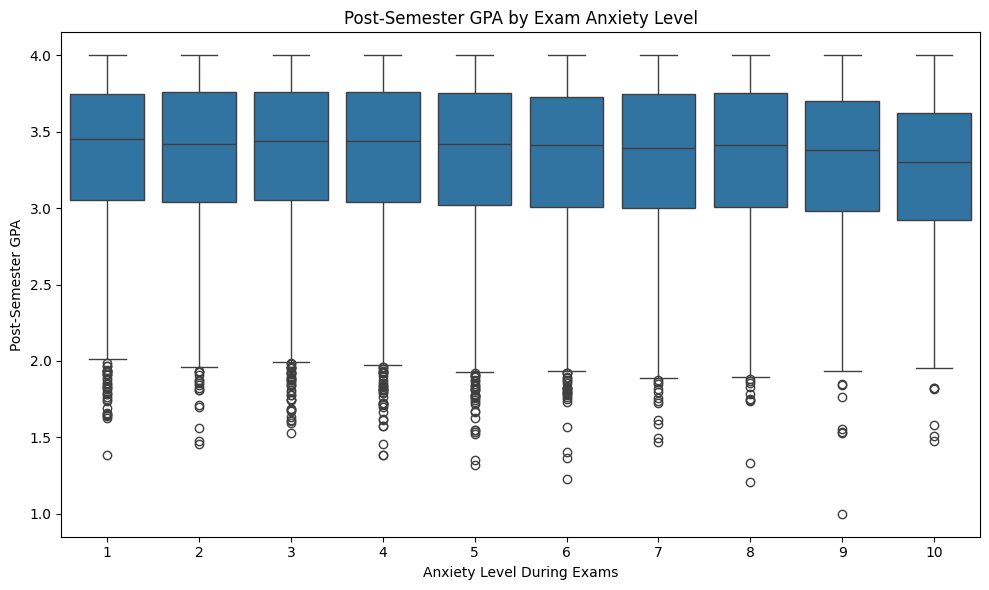

In [140]:
# Exam Anxiety vs Post-Semester GPA

plt.figure(figsize=(10, 6))

sns.boxplot(data=df,x='Anxiety_Level_During_Exams',y='Post_Semester_GPA')

plt.title('Post-Semester GPA by Exam Anxiety Level')
plt.xlabel('Anxiety Level During Exams')
plt.ylabel('Post-Semester GPA')
plt.tight_layout()
plt.show()

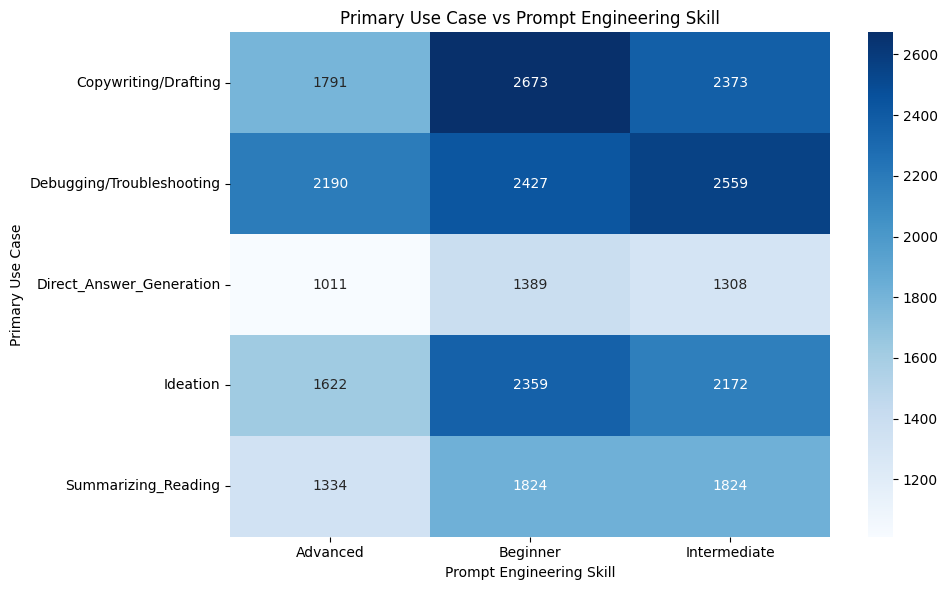

In [141]:
plt.figure(figsize=(10, 6))

cross_tab = pd.crosstab(df['Primary_Use_Case'],df['Prompt_Engineering_Skill'])
sns.heatmap(cross_tab,annot=True,fmt='d',cmap='Blues')
plt.title('Primary Use Case vs Prompt Engineering Skill')
plt.xlabel('Prompt Engineering Skill')
plt.ylabel('Primary Use Case')
plt.tight_layout()
plt.show()

# Multivariate

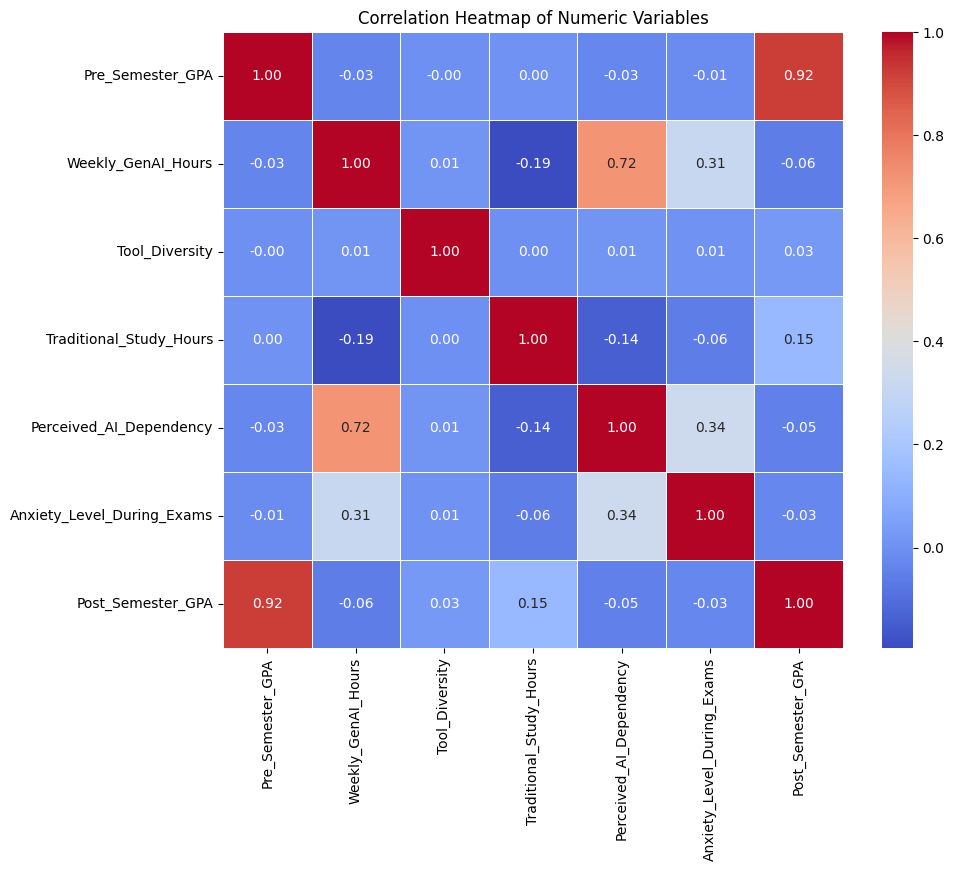

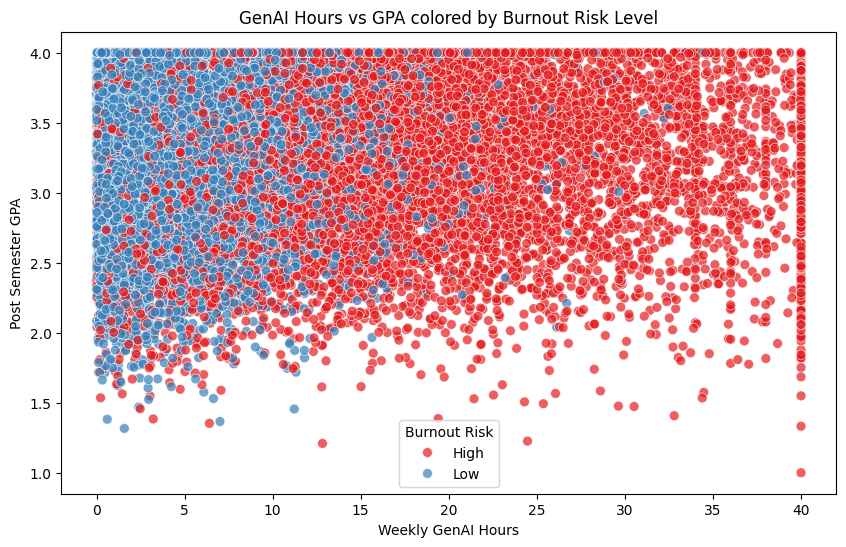

In [142]:
df_numeric = df[numeric_cols]

plt.figure(figsize=(10, 8))
correlation_matrix = df_numeric.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Weekly_GenAI_Hours',y='Post_Semester_GPA',hue='Burnout_Risk_Level',data=df,palette='Set1',alpha=0.7,s=50)
plt.title('GenAI Hours vs GPA colored by Burnout Risk Level')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('Post Semester GPA')
plt.legend(title='Burnout Risk')
plt.show()

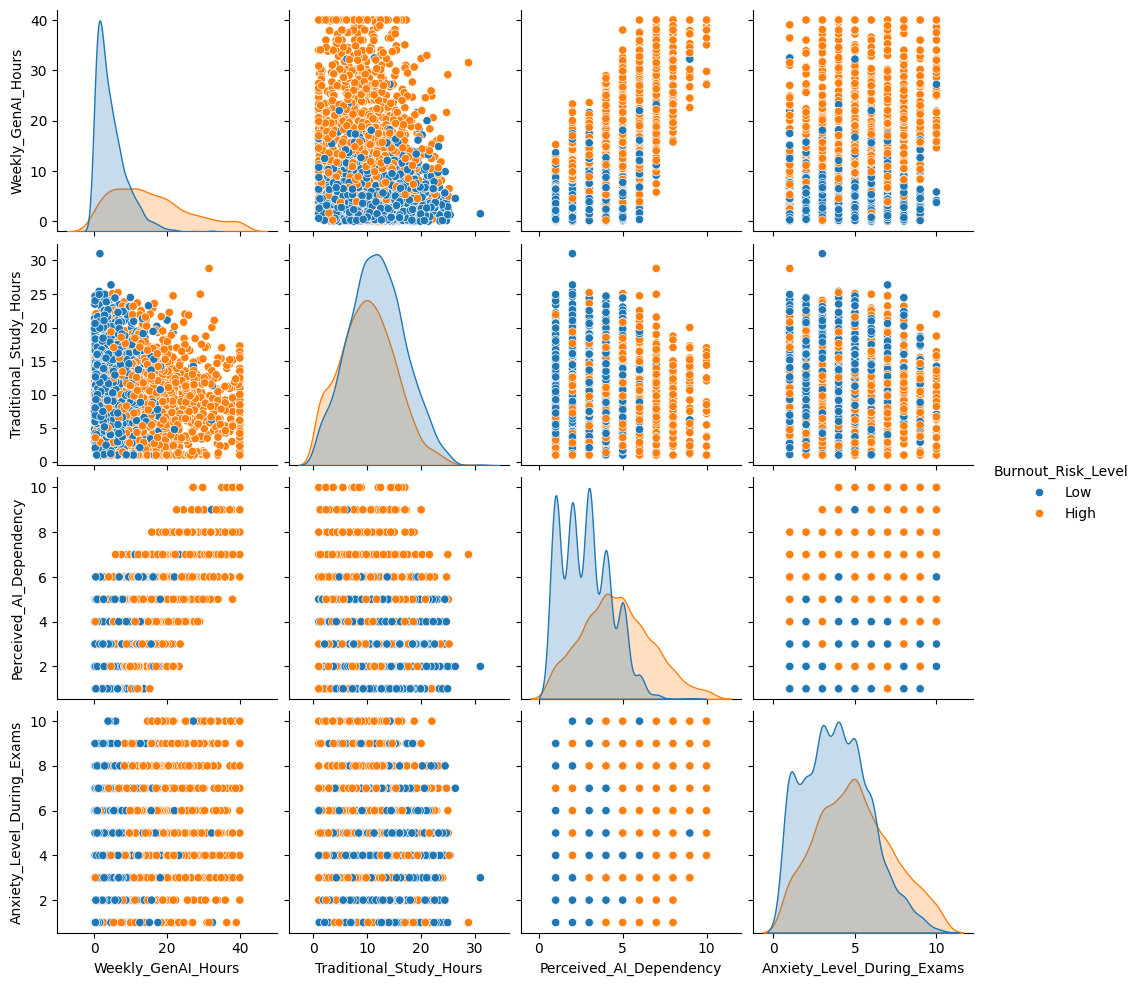

In [143]:
sample_df = df.sample(3000,random_state=42)

sns.pairplot(sample_df[
        [
            'Weekly_GenAI_Hours',
            'Traditional_Study_Hours',
            'Perceived_AI_Dependency',
            'Anxiety_Level_During_Exams',
            'Burnout_Risk_Level'
        ]
    ],
    hue='Burnout_Risk_Level'
)

plt.show()

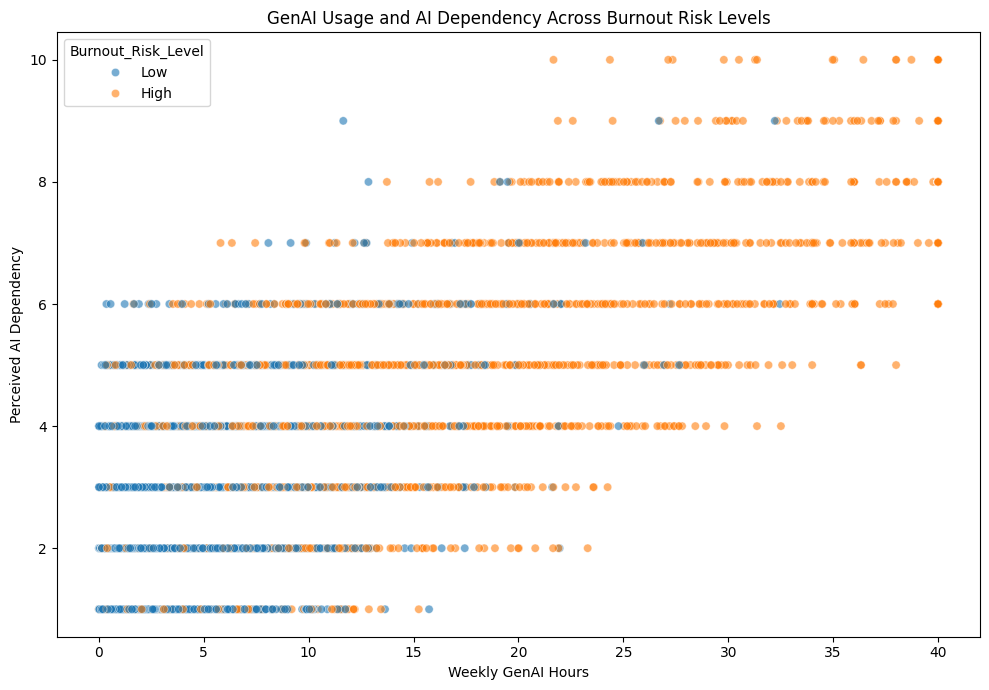

In [144]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='Weekly_GenAI_Hours',
    y='Perceived_AI_Dependency',
    hue='Burnout_Risk_Level',
    alpha=0.6
)

plt.title(
    'GenAI Usage and AI Dependency Across Burnout Risk Levels'
)

plt.xlabel('Weekly GenAI Hours')
plt.ylabel('Perceived AI Dependency')

plt.tight_layout()
plt.show()

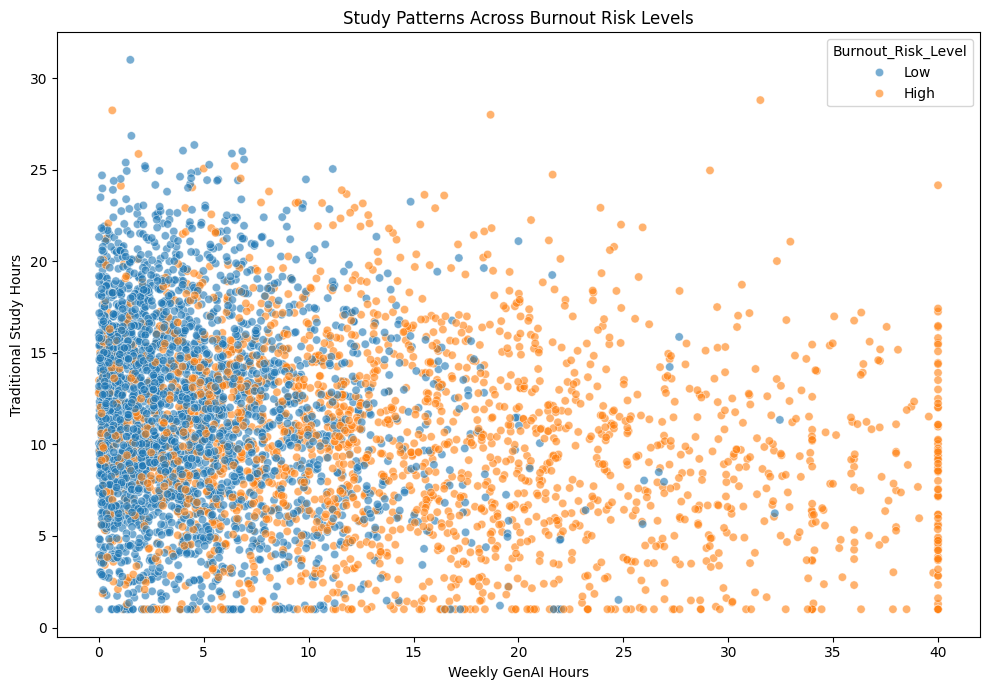

In [145]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='Weekly_GenAI_Hours',
    y='Traditional_Study_Hours',
    hue='Burnout_Risk_Level',
    alpha=0.6
)

plt.title(
    'Study Patterns Across Burnout Risk Levels'
)

plt.xlabel('Weekly GenAI Hours')
plt.ylabel('Traditional Study Hours')

plt.tight_layout()
plt.show()

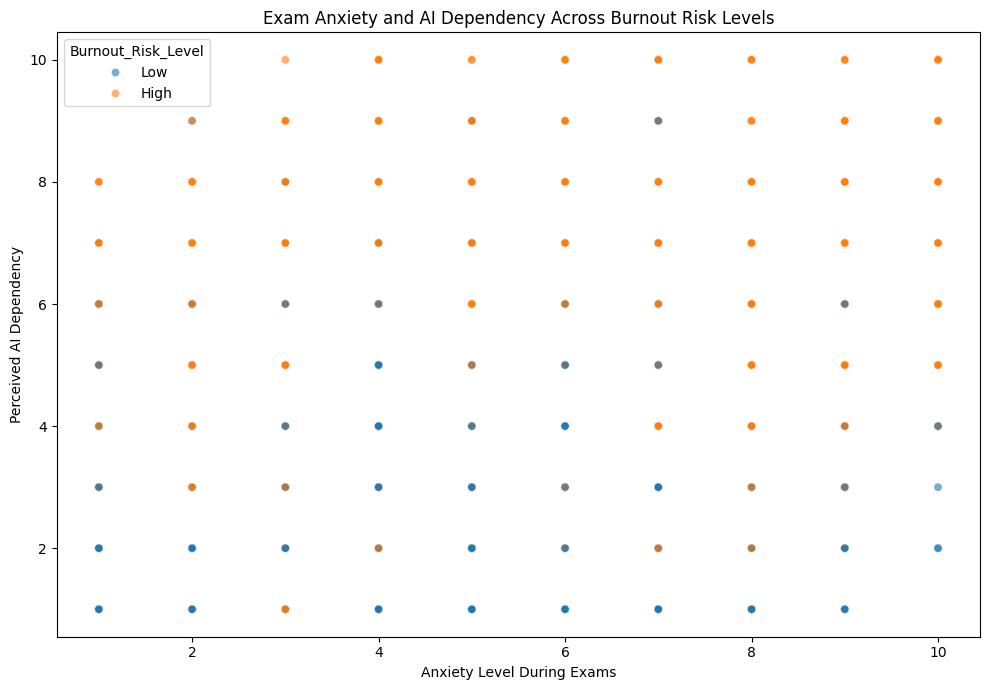

In [146]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='Anxiety_Level_During_Exams',
    y='Perceived_AI_Dependency',
    hue='Burnout_Risk_Level',
    alpha=0.6
)

plt.title(
    'Exam Anxiety and AI Dependency Across Burnout Risk Levels'
)

plt.xlabel('Anxiety Level During Exams')
plt.ylabel('Perceived AI Dependency')

plt.tight_layout()
plt.show()

In [147]:
from sklearn.model_selection import train_test_split

target_col = 'Burnout_Risk_Level'
leakage_cols = [
    'Post_Semester_GPA'
]


In [148]:
df.columns

Index(['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Burnout_Risk_Level'],
      dtype='object')

In [149]:
df.drop(axis=0, index=19295, inplace=True)

In [150]:
X = df.drop(columns=[target_col] + leakage_cols)
y = df[target_col]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Features shape: (28855, 12)
Target shape: (28855,)

Features:
['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams']


In [151]:
X.isnull().sum()

,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0
Perceived_AI_Dependency,0


In [152]:
X['Anxiety_Level_During_Exams'].isnull()

,Anxiety_Level_During_Exams
0,False
1,False
2,False
3,False
4,False
...,...
28851,False
28852,False
28853,False
28854,False


In [153]:
y.isnull().sum()

np.int64(0)

In [154]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (23084, 12)
X_test : (5771, 12)
y_train: (23084,)
y_test : (5771,)


In [155]:
comparison = pd.DataFrame({
    'Full Dataset (%)': y.value_counts(normalize=True) * 100,
    'Train (%)': y_train.value_counts(normalize=True) * 100,
    'Test (%)': y_test.value_counts(normalize=True) * 100
}).sort_index()

comparison.round(2)

,Full Dataset (%),Train (%),Test (%)
Burnout_Risk_Level,,,
High,43.27,43.28,43.27
Low,56.73,56.72,56.73


In [156]:
# FEATURE ENGINEERING FUNCTION

def create_features(data):
    data = data.copy()

    #Total Study Hours
    data['Total_Study_Hours'] = (
        data['Weekly_GenAI_Hours'] +
        data['Traditional_Study_Hours']
    )
    #Proportion of study time spent using GenAI
    data['GenAI_Study_Ratio'] = np.where(
        data['Total_Study_Hours'] > 0,
        data['Weekly_GenAI_Hours'] /
        data['Total_Study_Hours'],
        0
    )

    # AI Reliance Score
    data['AI_Reliance_Score'] = (
        data['Weekly_GenAI_Hours'] *
        data['Perceived_AI_Dependency']
    )

    #Study Balance
    data['Study_Balance'] = (
        data['Traditional_Study_Hours'] -
        data['Weekly_GenAI_Hours']
    )

    return data

In [157]:
X_train = create_features(X_train)
X_test = create_features(X_test)

In [158]:
new_features = ['Total_Study_Hours','GenAI_Study_Ratio','AI_Reliance_Score','Study_Balance']
X_train[
    [
        'Weekly_GenAI_Hours',
        'Traditional_Study_Hours',
        'Total_Study_Hours',
        'GenAI_Study_Ratio',
        'Perceived_AI_Dependency',
        'AI_Reliance_Score',
        'Study_Balance'
    ]
].head()

,Weekly_GenAI_Hours,Traditional_Study_Hours,Total_Study_Hours,GenAI_Study_Ratio,Perceived_AI_Dependency,AI_Reliance_Score,Study_Balance
863,1.95,13.58,15.53,0.125563,2,3.90,11.63
4215,32.88,11.31,44.19,0.744060,6,197.28,-21.57
21942,6.66,22.90,29.56,0.225304,1,6.66,16.24
12309,4.95,11.51,16.46,0.300729,4,19.80,6.56
14674,1.82,19.28,21.10,0.086256,2,3.64,17.46


In [159]:
X_train[new_features].describe()

,Total_Study_Hours,GenAI_Study_Ratio,AI_Reliance_Score,Study_Balance
count,23084.000000,23084.000000,23084.000000,23084.000000
mean,20.403805,0.391811,46.461178,1.916370
std,9.771983,0.258616,70.275665,11.497912
min,1.010000,0.000000,0.000000,-39.000000
25%,13.620000,0.169619,4.940000,-3.540000
50%,18.670000,0.360196,17.070000,4.330000
75%,25.240000,0.591088,55.080000,9.920000
max,64.150000,0.975610,400.000000,35.770000


In [160]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [161]:
numeric_features = X_train.select_dtypes(
    include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'bool', 'category']).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Total_Study_Hours', 'GenAI_Study_Ratio', 'AI_Reliance_Score', 'Study_Balance']

Categorical Features:
['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy']


In [162]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [163]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

In [164]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)

In [165]:
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()
print(f"Number of processed features: {len(feature_names)}")
display(
    pd.DataFrame({
        'Processed Feature': feature_names
    }).head(30)
)

Number of processed features: 33


,Processed Feature
0,num__Pre_Semester_GPA
1,num__Weekly_GenAI_Hours
2,num__Tool_Diversity
3,num__Traditional_Study_Hours
4,num__Perceived_AI_Dependency
5,num__Anxiety_Level_During_Exams
6,num__Total_Study_Hours
7,num__GenAI_Study_Ratio
8,num__AI_Reliance_Score
9,num__Study_Balance


In [166]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
from sklearn.model_selection import (StratifiedKFold,GridSearchCV,cross_validate)

In [167]:
# CLASSIFICATION MODELS

models = {

    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),

    'SVM': SVC(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    'Naive Bayes': GaussianNB()
}

In [168]:
#MODEL PIPELINES

pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

print("Pipelines created:")
for name in pipelines:
    print("-", name)

Pipelines created:
- Logistic Regression
- KNN
- SVM
- Random Forest
- Naive Bayes


In [169]:
#MODEL COMPARISON

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

results = []
for name, pipeline in pipelines.items():
    scores = cross_validate(pipeline,X_train,y_train,cv=cv,
scoring=[
            'accuracy',
            'precision_macro',
            'recall_macro',
            'f1_macro'
        ],
        n_jobs=-1
    )

    results.append({

        'Model': name,

        'Accuracy': scores[
            'test_accuracy'
        ].mean(),

        'Precision': scores[
            'test_precision_macro'
        ].mean(),

        'Recall': scores[
            'test_recall_macro'
        ].mean(),

        'Macro F1': scores[
            'test_f1_macro'
        ].mean()
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'Macro F1',
    ascending=False
).reset_index(drop=True)

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,Macro F1
0,Logistic Regression,0.7941,0.7966,0.7818,0.7858
1,Random Forest,0.7904,0.7931,0.7777,0.7817
2,SVM,0.7909,0.8003,0.7742,0.7794
3,Naive Bayes,0.7805,0.7946,0.7610,0.7662
4,KNN,0.7596,0.7599,0.7464,0.7497


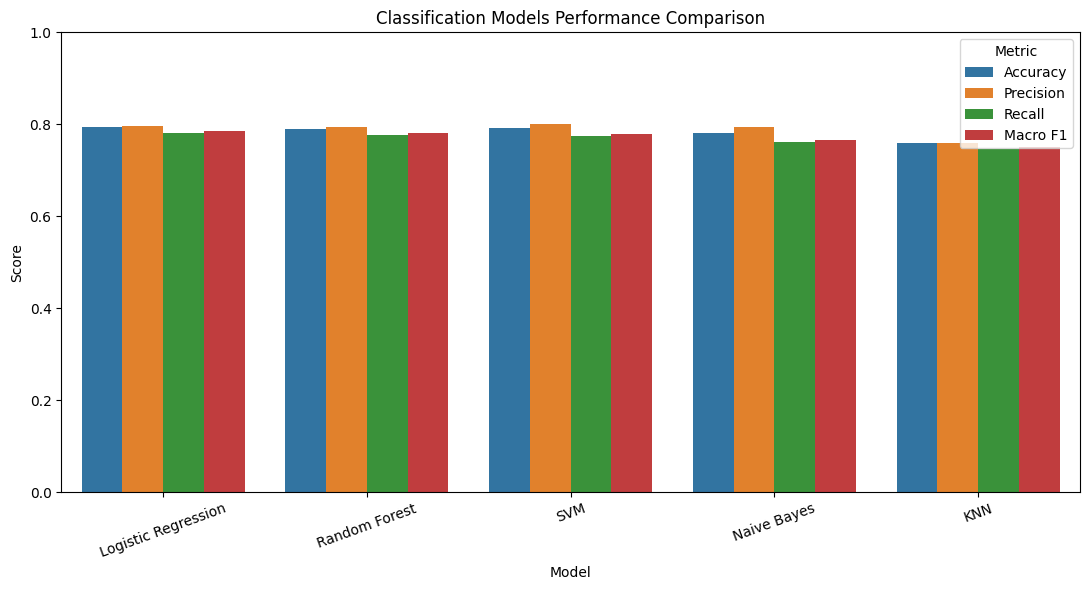

In [170]:
#MODEL PERFORMANCE COMPARISON

results_melted = results_df.melt(
    id_vars='Model',
    value_vars=['Accuracy','Precision','Recall','Macro F1'],var_name='Metric',value_name='Score')

plt.figure(figsize=(11, 6))
sns.barplot(data=results_melted,x='Model',y='Score',hue='Metric')

plt.title('Classification Models Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [171]:
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,Macro F1
0,Logistic Regression,0.7941,0.7966,0.7818,0.7858
1,Random Forest,0.7904,0.7931,0.7777,0.7817
2,SVM,0.7909,0.8003,0.7742,0.7794
3,Naive Bayes,0.7805,0.7946,0.7610,0.7662
4,KNN,0.7596,0.7599,0.7464,0.7497


In [172]:
# GRID SEARCH: LOGISTIC REGRESSION

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_params = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs']
}

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_params,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True
)

logistic_grid.fit(X_train, y_train)

print("Best Logistic Parameters:")
print(logistic_grid.best_params_)

print("\nBest Logistic Macro F1:")
print(logistic_grid.best_score_)

Best Logistic Parameters:
{'model__C': 1, 'model__solver': 'lbfgs'}

Best Logistic Macro F1:
0.7857775341809781


In [ ]:
# GRID SEARCH: SVM

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(
        random_state=42
    ))
])

svm_params = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale']
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_params,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True
)

svm_grid.fit(X_train, y_train)

print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("\nBest SVM Macro F1:")
print(svm_grid.best_score_)

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
#GRID SEARCH: RANDOM FOREST

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest Macro F1:")
print(rf_grid.best_score_)

In [ ]:
# GRID SEARCH RESULTS
grid_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM',
        'Random Forest'
    ],

    'Best Macro F1': [
        logistic_grid.best_score_,
        svm_grid.best_score_,
        rf_grid.best_score_
    ]
})

grid_results = grid_results.sort_values(
    'Best Macro F1',
    ascending=False
).reset_index(drop=True)

display(
    grid_results.round(4)
)

In [ ]:
# BEST MODEL

grid_objects = {
    'Logistic Regression': logistic_grid,
    'SVM': svm_grid,
    'Random Forest': rf_grid
}

best_model_name = grid_results.iloc[0]['Model']

best_grid = grid_objects[best_model_name]

best_model = best_grid.best_estimator_

print("Best Model:")
print(best_model_name)

print("\nBest Parameters:")
print(best_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(best_grid.best_score_, 4))

In [ ]:
# FINAL TEST EVALUATION

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred,average='macro')

recall = recall_score(y_test,y_pred,average='macro')

f1 = f1_score(y_test,y_pred,average='macro')

print("FINAL TEST RESULTS")
print("=" * 40)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision Macro: {precision:.4f}")
print(f"Recall Macro   : {recall:.4f}")
print(f"Macro F1       : {f1:.4f}")

In [ ]:
# CLASSIFICATION REPORT

print(
    classification_report(y_test,y_pred,labels=['Low', 'High'],target_names=['Low', 'High'],digits=4)
)

In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test,y_pred,labels=['Low', 'High'])

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'High'],
    yticklabels=['Low', 'High']
)

plt.title(
    f'Confusion Matrix — {best_model_name}'
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

In [ ]:
# HIGH BURNOUT PERFORMANCE

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

high_metrics = report['High']

print("HIGH BURNOUT CLASS")
print("=" * 40)

print(
    f"Precision: {high_metrics['precision']:.4f}"
)

print(
    f"Recall   : {high_metrics['recall']:.4f}"
)

print(
    f"F1-score : {high_metrics['f1-score']:.4f}"
)

In [ ]:
# ERROR ANALYSIS

error_analysis = X_test.copy()

error_analysis['Actual'] = y_test
error_analysis['Predicted'] = y_pred

misclassified = error_analysis[
    error_analysis['Actual'] != error_analysis['Predicted']
].copy()

print(
    "Number of misclassified students:",
    len(misclassified)
)

print(
    "Misclassification rate:",
    round(
        len(misclassified) / len(y_test) * 100,
        2
    ),
    "%"
)

display(
    misclassified.head(20)
)

In [ ]:
#RANDOM FOREST FEATURE IMPORTANCE

if best_model_name == 'Random Forest':

    fitted_preprocessor = (
        best_model
        .named_steps['preprocessor']
    )

    rf_model = (
        best_model
        .named_steps['model']
    )

    feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
    )

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        'Importance',
        ascending=False
    )

    display(
        importance_df.head(20)
    )

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=importance_df.head(15),
        x='Importance',
        y='Feature'
    )

    plt.title(
        'Top 15 Feature Importances'
    )

    plt.tight_layout()
    plt.show()